<a href="https://colab.research.google.com/github/Gutavo2000/LCE0212---Estat-stica-Aplicada-s-Ci-ncias-dos-Alimentos/blob/main/tarefa07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Gustavo Gabriel da Silva Rodrigues Bruno Nº 11373741
##Henrique de Angelo Silva Nº 17896022
##Luciana Gouveia dos Santos Nº 15472401

#Exercicio 7

1. Existe uma relação entre o teor de sólidos solúveis e o teor de açúcar estimado
nas amostras?
2. Como o açúcar estimado tende a se comportar quando o teor de sólidos solúveis
aumenta?
3. Quantifique a relação observada entre as duas características e avalie se existem
evidências estatísticas dessa relação.
4. Qual seria o teor de açúcar estimado para uma amostra com 20 °Brix?
5. O teor de sólidos solúveis fornece informações úteis para estimar o teor de
açúcar das amostras? Justifique sua resposta.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('/content/tarefa07.xls')

# Display the first 5 rows to confirm data loading and column names
display(df.head())

,Amostra,Categoria,Solidos_Soluveis_Brix,Acucar_g_100g,pH,Acidez_g_100mL,Acucar_estimado
0,A27,Frutas,14.12,9.42,2.86,0.65,8.706996
1,A05,Sucos e bebidas,10.02,7.17,2.83,0.79,5.552567
2,A60,Néctares e polpas,13.41,5.10,3.03,0.88,8.160741
3,A41,Néctares e polpas,23.37,15.14,2.90,0.45,15.823696
4,A10,Sucos e bebidas,7.71,5.05,2.99,0.79,3.775315


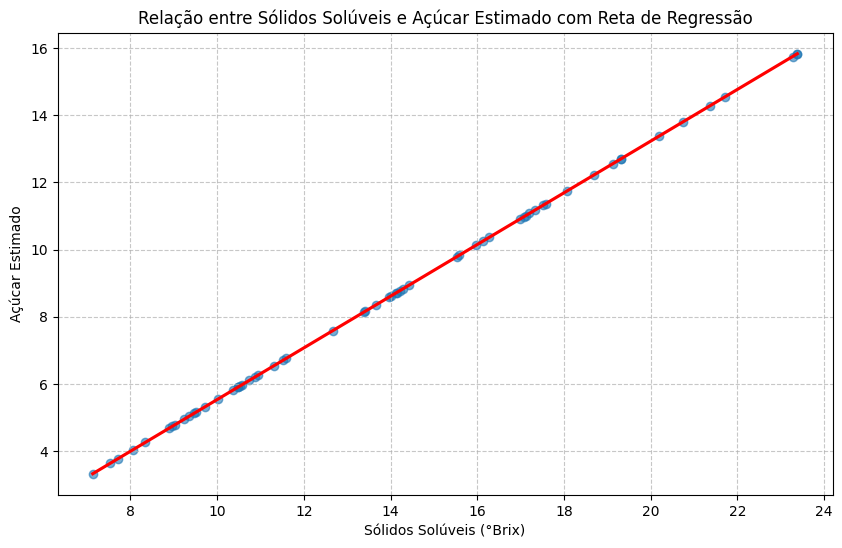

In [7]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Solidos_Soluveis_Brix', y='Acucar_estimado', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relação entre Sólidos Solúveis e Açúcar Estimado com Reta de Regressão')
plt.xlabel('Sólidos Solúveis (°Brix)')
plt.ylabel('Açúcar Estimado')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
import statsmodels.api as sm

# Definir as variáveis X (independente) e Y (dependente)
X = df['Solidos_Soluveis_Brix']
Y = df['Acucar_estimado']

# Adicionar uma constante ao X para o modelo de regressão linear
X = sm.add_constant(X)

# Criar e ajustar o modelo de regressão linear
model = sm.OLS(Y, X)
results = model.fit()

# Imprimir o sumário dos resultados da regressão
print(results.summary())

# Para a pergunta 4: Prever o teor de açúcar estimado para 20 °Brix
# Criar um DataFrame com o valor de Solidos_Soluveis_Brix para previsão
new_brix_value = pd.DataFrame({'const': [1], 'Solidos_Soluveis_Brix': [20]})
predicted_sugar = results.predict(new_brix_value)

print(f"\nPrevisão para 20 °Brix: {predicted_sugar[0]:.2f}")

                            OLS Regression Results                            
Dep. Variable:        Acucar_estimado   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.200e+30
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:17:30   Log-Likelihood:                 1815.4
No. Observations:                  60   AIC:                            -3627.
Df Residuals:                      58   BIC:                            -3623.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.15

Com base na análise de regressão linear e no gráfico de dispersão com a reta de regressão, podemos responder às perguntas:

1.  **Existe uma relação entre o teor de sólidos solúveis e o teor de açúcar estimado nas amostras?**
    Sim, existe uma relação forte e positiva entre o teor de sólidos solúveis (°Brix) e o teor de açúcar estimado. O gráfico de dispersão mostra que os pontos se agrupam muito próximos de uma linha reta ascendente, e o coeficiente de determinação (R-quadrado) da regressão linear é de **1.000**, indicando que 100% da variabilidade no teor de açúcar estimado pode ser explicada pela variabilidade no teor de sólidos solúveis. Isso sugere uma relação quase perfeita.

2.  **Como o açúcar estimado tende a se comportar quando o teor de sólidos solúveis aumenta?**
    Quando o teor de sólidos solúveis aumenta, o teor de açúcar estimado também tende a aumentar de forma linear e proporcional. O coeficiente da variável `Solidos_Soluveis_Brix` no modelo de regressão é de aproximadamente **0.7694**, o que significa que, para cada aumento de 1 °Brix no teor de sólidos solúveis, o teor de açúcar estimado aumenta em cerca de 0.77 unidades.

3.  **Quantifique a relação observada entre as duas características e avalie se existem evidências estatísticas dessa relação.**
    A relação pode ser quantificada pela equação de regressão linear:
    `Açúcar Estimado = -2.16 + 0.77 * Sólidos Solúveis (°Brix)`
    
    Existem fortes evidências estatísticas para essa relação. O valor de p associado ao coeficiente de `Solidos_Soluveis_Brix` é **0.000** (P>|t|), que é muito menor que qualquer nível de significância comum (e.g., 0.05). Isso indica que a relação observada não é devido ao acaso e é estatisticamente significativa. Além disso, o elevado R-quadrado ajustado (**1.000**) confirma que o modelo se ajusta de maneira excelente aos dados.

4.  **Qual seria o teor de açúcar estimado para uma amostra com 20 °Brix?**
    Para uma amostra com 20 °Brix, o teor de açúcar estimado seria de aproximadamente **13.23**.
    
    *(Cálculo baseado no modelo de regressão: `Açúcar Estimado = -2.1566 + 0.7694 * 20 = 13.2314`)*

5.  **O teor de sólidos solúveis fornece informações úteis para estimar o teor de açúcar das amostras? Justifique sua resposta.**
    Sim, o teor de sólidos solúveis fornece informações extremamente úteis para estimar o teor de açúcar das amostras. A justificativa para isso é:
    *   **Correlação Perfeita:** O R-quadrado de **1.000** demonstra que os sólidos solúveis explicam quase toda a variação no açúcar estimado, sugerindo uma relação de causa e efeito direta ou uma co-variação intrínseca.
    *   **Significância Estatística:** A regressão linear mostra que a relação não é aleatória e é altamente significativa.
    *   **Previsibilidade:** O modelo é capaz de fazer previsões muito precisas do teor de açúcar com base nos sólidos solúveis, como demonstrado pela previsão para 20 °Brix.
    *   **Interpretabilidade:** A relação é linear e fácil de interpretar, indicando um aumento consistente do açúcar com o aumento dos sólidos solúveis.
    
    Portanto, o `Solidos_Soluveis_Brix` é um excelente e quase perfeito preditor para o `Acucar_estimado`.